In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Project color palette

# Main project colors based on the selected visual identity
PROJECT_COLORS = {
    "black": "#000000",
    "dark_gray": "#4A4A4A",
    "green": "#00BF63",
    "primary_blue": "#024DC5",
    "bright_blue": "#0962EF",
    "deep_navy": "#050818",
    "muted_blue": "#3567A1",
    "soft_azure": "#5F8FB3",
    "light_azure": "#AED9F1",
    "light_gray": "#D2D2D2",
    "white": "#FFFFFF",
    "gradient_start": "#0370FF",
    "gradient_end": "#000E59"}

# General palette for non-cluster visuals
MAIN_PALETTE = [
    PROJECT_COLORS["primary_blue"],
    PROJECT_COLORS["green"],
    PROJECT_COLORS["deep_navy"],
    PROJECT_COLORS["bright_blue"],
    PROJECT_COLORS["light_gray"],
    PROJECT_COLORS["muted_blue"],
    PROJECT_COLORS["dark_gray"],
    PROJECT_COLORS["soft_azure"]]

# Stable cluster colors for clearer visual separation
CLUSTER_PALETTE = {
    0: PROJECT_COLORS["soft_azure"],
    1: PROJECT_COLORS["green"],
    2: PROJECT_COLORS["dark_gray"],
    3: PROJECT_COLORS["black"],
    4: PROJECT_COLORS["primary_blue"],
    5: PROJECT_COLORS["deep_navy"],
    -1: PROJECT_COLORS["light_gray"]}

# Ordered list version of the cluster palette for convenience
CLUSTER_COLOR_LIST = [
    PROJECT_COLORS["soft_azure"],
    PROJECT_COLORS["green"],
    PROJECT_COLORS["dark_gray"],
    PROJECT_COLORS["black"],
    PROJECT_COLORS["primary_blue"],
    PROJECT_COLORS["deep_navy"]]

# Sequential blue colormap for heatmaps and intensity-based visuals
BLUE_CMAP = LinearSegmentedColormap.from_list(
    "project_blues",
    [
        PROJECT_COLORS["light_azure"],
        PROJECT_COLORS["soft_azure"],
        PROJECT_COLORS["muted_blue"],
        PROJECT_COLORS["primary_blue"],
        PROJECT_COLORS["deep_navy"]])

# Global plot styling
sns.set_theme(style="whitegrid", palette=MAIN_PALETTE)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.titlesize"] = 16

plt.rcParams["axes.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["figure.facecolor"] = PROJECT_COLORS["white"]
plt.rcParams["savefig.facecolor"] = PROJECT_COLORS["white"]

plt.rcParams["axes.edgecolor"] = PROJECT_COLORS["light_gray"]
plt.rcParams["grid.color"] = PROJECT_COLORS["light_gray"]
plt.rcParams["text.color"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["axes.labelcolor"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["xtick.color"] = PROJECT_COLORS["deep_navy"]
plt.rcParams["ytick.color"] = PROJECT_COLORS["deep_navy"]

In [3]:
DATA_PATH = Path("../1. Data/Customer Data.csv")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.9007,0.8182,95.4000,0.0000,95.4000,0.0000,0.1667,0.0000,0.0833,0.0000,0,2,"1,000.0000",201.8021,139.5098,0.0000,12
1,C10002,"3,202.4674",0.9091,0.0000,0.0000,0.0000,"6,442.9455",0.0000,0.0000,0.0000,0.2500,4,0,"7,000.0000","4,103.0326","1,072.3402",0.2222,12
2,C10003,"2,495.1489",1.0000,773.1700,773.1700,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0,12,"7,500.0000",622.0667,627.2848,0.0000,12
3,C10004,"1,666.6705",0.6364,"1,499.0000","1,499.0000",0.0000,205.7880,0.0833,0.0833,0.0000,0.0833,1,1,"7,500.0000",0.0000,NaN,0.0000,12
4,C10005,817.7143,1.0000,16.0000,16.0000,0.0000,0.0000,0.0833,0.0833,0.0000,0.0000,0,1,"1,200.0000",678.3348,244.7912,0.0000,12


In [4]:
df_eda = df.copy()
numeric_cols = df_eda.drop(columns="CUST_ID").columns.tolist()
df_eda["MINIMUM_PAYMENTS"] = df_eda["MINIMUM_PAYMENTS"].fillna(df_eda["MINIMUM_PAYMENTS"].median())
df_eda["CREDIT_LIMIT"] = df_eda["CREDIT_LIMIT"].fillna(df_eda["CREDIT_LIMIT"].median())

In [5]:
# Create helper log-transformed columns for highly skewed monetary features
log_features = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"]

for col in log_features:
    df_eda[f"log_{col}"] = np.log1p(df_eda[col])

# Create readable behavioral flags for selected customer actions
df_eda["made_purchases"] = (df_eda["PURCHASES"] > 0).astype(int)
df_eda["used_oneoff_purchases"] = (df_eda["ONEOFF_PURCHASES"] > 0).astype(int)
df_eda["used_installments"] = (df_eda["INSTALLMENTS_PURCHASES"] > 0).astype(int)
df_eda["used_cash_advance"] = (df_eda["CASH_ADVANCE"] > 0).astype(int)
df_eda["made_full_payment"] = (df_eda["PRC_FULL_PAYMENT"] > 0).astype(int)

# Create a readable label for full-payment behavior
df_eda["full_payment_label"] = np.where(
    df_eda["made_full_payment"] == 1,
    "Has full payment activity",
    "No full payment activity")

# Print a quick confirmation message
print(f"EDA dataset shape: {df_eda.shape}")
display(df_eda)
df_eda.info()

EDA dataset shape: (8950, 32)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,log_BALANCE,log_PURCHASES,log_ONEOFF_PURCHASES,log_INSTALLMENTS_PURCHASES,log_CASH_ADVANCE,log_CREDIT_LIMIT,log_PAYMENTS,log_MINIMUM_PAYMENTS,made_purchases,used_oneoff_purchases,used_installments,used_cash_advance,made_full_payment,full_payment_label
0,C10001,40.9007,0.8182,95.4000,0.0000,95.4000,0.0000,0.1667,0.0000,0.0833,0.0000,0,2,"1,000.0000",201.8021,139.5098,0.0000,12,3.7353,4.5685,0.0000,4.5685,0.0000,6.9088,5.3122,4.9453,1,0,1,0,0,No full payment activity
1,C10002,"3,202.4674",0.9091,0.0000,0.0000,0.0000,"6,442.9455",0.0000,0.0000,0.0000,0.2500,4,0,"7,000.0000","4,103.0326","1,072.3402",0.2222,12,8.0720,0.0000,0.0000,0.0000,8.7709,8.8538,8.3197,6.9785,0,0,0,1,1,Has full payment activity
2,C10003,"2,495.1489",1.0000,773.1700,773.1700,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0,12,"7,500.0000",622.0667,627.2848,0.0000,12,7.8225,6.6518,6.6518,0.0000,0.0000,8.9228,6.4347,6.4430,1,1,0,0,0,No full payment activity
3,C10004,"1,666.6705",0.6364,"1,499.0000","1,499.0000",0.0000,205.7880,0.0833,0.0833,0.0000,0.0833,1,1,"7,500.0000",0.0000,312.3439,0.0000,12,7.4192,7.3132,7.3132,0.0000,5.3317,8.9228,0.0000,5.7473,1,1,0,1,0,No full payment activity
4,C10005,817.7143,1.0000,16.0000,16.0000,0.0000,0.0000,0.0833,0.0833,0.0000,0.0000,0,1,"1,200.0000",678.3348,244.7912,0.0000,12,6.7077,2.8332,2.8332,0.0000,0.0000,7.0909,6.5211,5.5045,1,1,0,0,0,No full payment activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.4935,1.0000,291.1200,0.0000,291.1200,0.0000,1.0000,0.0000,0.8333,0.0000,0,6,"1,000.0000",325.5945,48.8864,0.5000,6,3.3842,5.6772,0.0000,5.6772,0.0000,6.9088,5.7887,3.9097,1,0,1,0,1,Has full payment activity
8946,C19187,19.1832,1.0000,300.0000,0.0000,300.0000,0.0000,1.0000,0.0000,0.8333,0.0000,0,6,"1,000.0000",275.8613,312.3439,0.0000,6,3.0049,5.7071,0.0000,5.7071,0.0000,6.9088,5.6235,5.7473,1,0,1,0,0,No full payment activity
8947,C19188,23.3987,0.8333,144.4000,0.0000,144.4000,0.0000,0.8333,0.0000,0.6667,0.0000,0,5,"1,000.0000",81.2708,82.4184,0.2500,6,3.1945,4.9795,0.0000,4.9795,0.0000,6.9088,4.4100,4.4239,1,0,1,0,1,Has full payment activity
8948,C19189,13.4576,0.8333,0.0000,0.0000,0.0000,36.5588,0.0000,0.0000,0.0000,0.1667,2,0,500.0000,52.5500,55.7556,0.2500,6,2.6712,0.0000,0.0000,0.0000,3.6259,6.2166,3.9806,4.0388,0,0,0,1,1,Has full payment activity


<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [8]:
# Create readable behavioral labels for purchase type and cash advance usage

# Define purchase-behavior conditions
purchase_conditions = [
    (df_eda["made_purchases"] == 0),
    (df_eda["used_oneoff_purchases"] == 1) & (df_eda["used_installments"] == 0),
    (df_eda["used_oneoff_purchases"] == 0) & (df_eda["used_installments"] == 1),
    (df_eda["used_oneoff_purchases"] == 1) & (df_eda["used_installments"] == 1)]

# Define readable labels for each purchase-behavior condition
purchase_labels = [
    "No purchases",
    "One-off only",
    "Installments only",
    "Both purchase types"]

# Create the final purchase-mix label column
df_eda["purchase_mix_label"] = np.select(
    purchase_conditions,
    purchase_labels,
    default="Other")

# Create a readable cash-advance usage label
df_eda["cash_advance_label"] = np.where(
    df_eda["used_cash_advance"] == 1,
    "Used cash advance",
    "No cash advance")

# Quick check of the new labels
display(df_eda[["purchase_mix_label", "cash_advance_label"]].head())

,purchase_mix_label,cash_advance_label
0,Installments only,No cash advance
1,No purchases,Used cash advance
2,One-off only,No cash advance
3,One-off only,Used cash advance
4,One-off only,No cash advance


,customer_pct
purchase_mix_label,
One-off only,20.9385
No purchases,22.8380
Installments only,25.2291
Both purchase types,30.9944


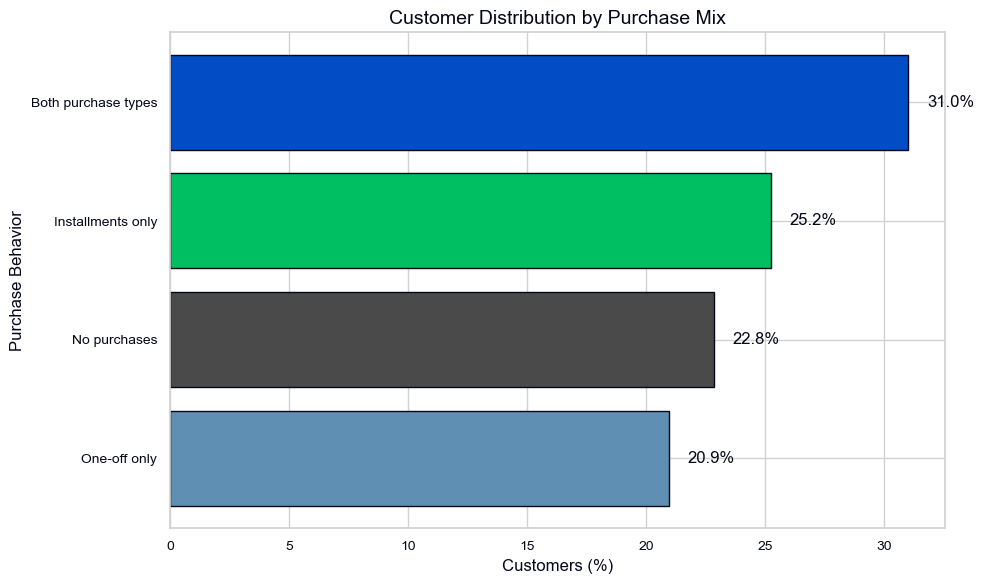

In [ ]:
# Build a summary table for purchase-mix behavior
purchase_mix_summary = (
    df_eda["purchase_mix_label"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("customer_pct")
    .sort_values(ascending=True))

display(purchase_mix_summary.to_frame())

purchase_mix_colors = {
    "No purchases": PROJECT_COLORS["dark_gray"],
    "One-off only": PROJECT_COLORS["soft_azure"],
    "Installments only": PROJECT_COLORS["green"],
    "Both purchase types": PROJECT_COLORS["primary_blue"],
    "Other": PROJECT_COLORS["light_gray"]}

# Create the figure
plt.figure(figsize=(10, 6))
plt.barh(
    y=purchase_mix_summary.index,
    width=purchase_mix_summary.values,
    color=[purchase_mix_colors[label] for label in purchase_mix_summary.index],
    edgecolor=PROJECT_COLORS["deep_navy"])
for i, value in enumerate(purchase_mix_summary.values):
    plt.text(value + 0.8, i, f"{value:.1f}%", va="center")
plt.title("Customer Distribution by Purchase Mix")
plt.xlabel("Customers (%)")
plt.ylabel("Purchase Behavior")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "01_customer_distribution_by_purchase_mix.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [10]:
# Create a temporary DataFrame only for payment-behavior visuals
payment_plot_df = df_eda[
    [
        "BALANCE",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "CREDIT_LIMIT",
        "PRC_FULL_PAYMENT",
        "CASH_ADVANCE"]].copy()

# Create log-transformed variables for scatterplots
payment_plot_df["log_BALANCE"] = np.log1p(payment_plot_df["BALANCE"])
payment_plot_df["log_PAYMENTS"] = np.log1p(payment_plot_df["PAYMENTS"])

# Create behavioral ratio features for comparison
payment_plot_df["balance_to_limit"] = payment_plot_df["BALANCE"] / payment_plot_df["CREDIT_LIMIT"]
payment_plot_df["payment_to_balance"] = payment_plot_df["PAYMENTS"] / (payment_plot_df["BALANCE"] + 1)

# Cap extreme values at the 99th percentile for visualization only
balance_to_limit_cap = payment_plot_df["balance_to_limit"].quantile(0.99)
payment_to_balance_cap = payment_plot_df["payment_to_balance"].quantile(0.99)

payment_plot_df["balance_to_limit_capped"] = payment_plot_df["balance_to_limit"].clip(upper=balance_to_limit_cap)
payment_plot_df["payment_to_balance_capped"] = payment_plot_df["payment_to_balance"].clip(upper=payment_to_balance_cap)

# Create temporary readable labels used only for plotting
payment_plot_df["cash_advance_group"] = np.where(
    payment_plot_df["CASH_ADVANCE"] > 0,
    "Used cash advance",
    "No cash advance")

payment_plot_df["full_payment_group"] = np.where(
    payment_plot_df["PRC_FULL_PAYMENT"] > 0,
    "Has full payment activity",
    "No full payment activity")

print(f"Temporary payment plot dataset shape: {payment_plot_df.shape}")

Temporary payment plot dataset shape: (8950, 14)


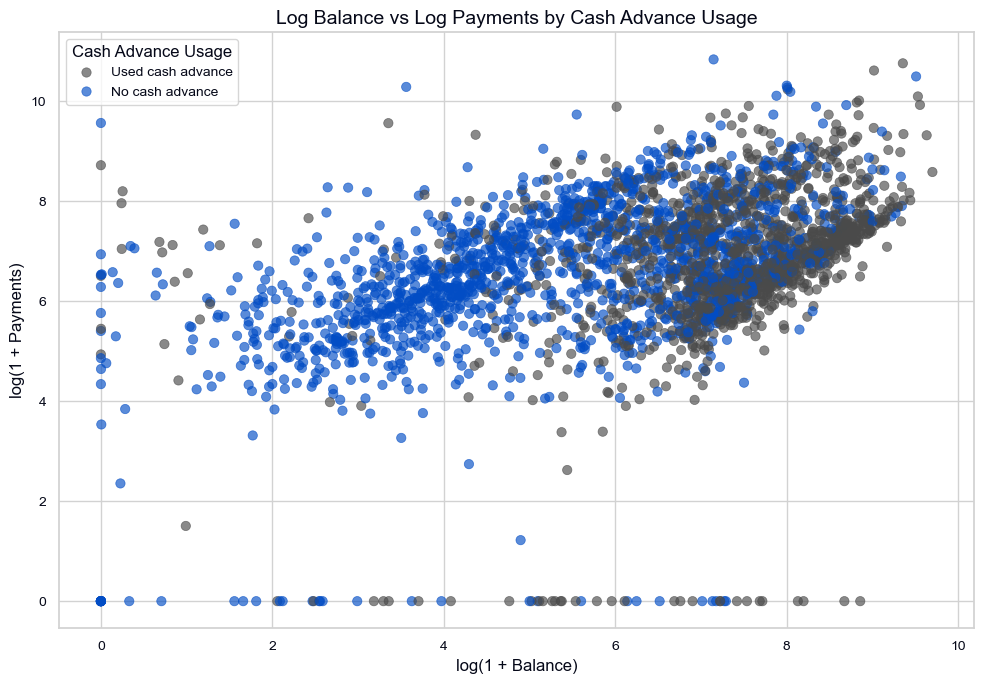

In [ ]:
# Take a reproducible sample to reduce overplotting
payment_scatter_sample = payment_plot_df.sample(
    n=min(3000, len(payment_plot_df)),
    random_state=42)


plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=payment_scatter_sample,
    x="log_BALANCE",
    y="log_PAYMENTS",
    hue="cash_advance_group",
    palette={
        "No cash advance": PROJECT_COLORS["primary_blue"],
        "Used cash advance": PROJECT_COLORS["dark_gray"]
    },
    alpha=0.65,
    s=45,
    edgecolor=None)
plt.title("Log Balance vs Log Payments by Cash Advance Usage")
plt.xlabel("log(1 + Balance)")
plt.ylabel("log(1 + Payments)")
plt.legend(title="Cash Advance Usage")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_log_balance_vs_log_payments_by_cash_advance.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

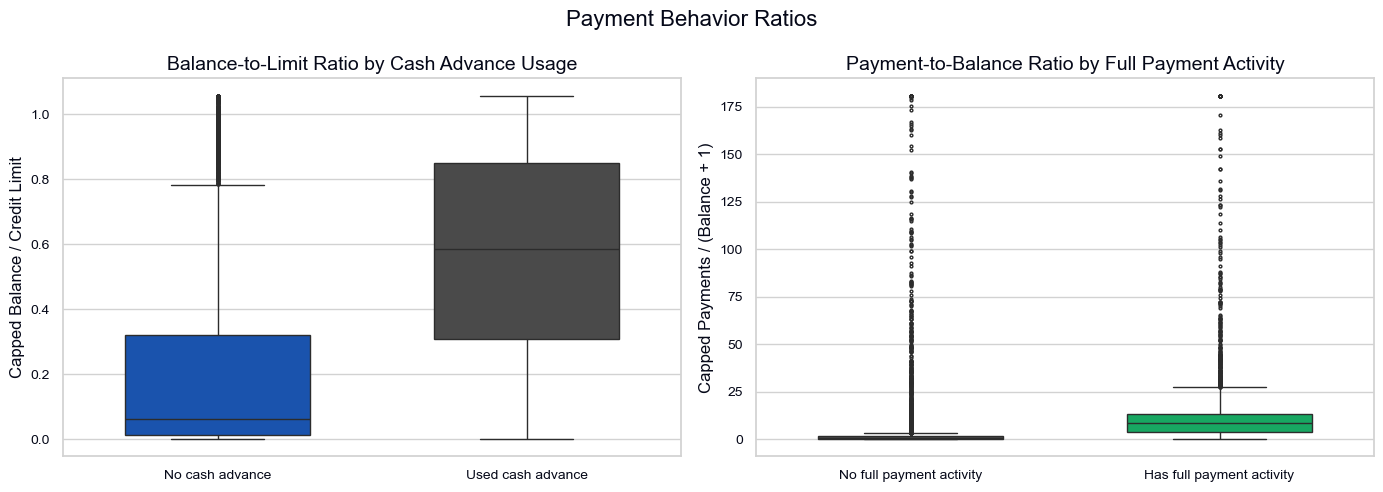

In [ ]:
# Create a 1x2 grid of boxplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(
    data=payment_plot_df,
    x="cash_advance_group",
    y="balance_to_limit_capped",
    order=["No cash advance", "Used cash advance"],
    palette={
        "No cash advance": PROJECT_COLORS["primary_blue"],
        "Used cash advance": PROJECT_COLORS["dark_gray"]
    },
    width=0.6,
    fliersize=2,
    ax=axes[0])
axes[0].set_title("Balance-to-Limit Ratio by Cash Advance Usage")
axes[0].set_xlabel("")
axes[0].set_ylabel("Capped Balance / Credit Limit")

sns.boxplot(
    data=payment_plot_df,
    x="full_payment_group",
    y="payment_to_balance_capped",
    order=["No full payment activity", "Has full payment activity"],
    palette={
        "No full payment activity": PROJECT_COLORS["dark_gray"],
        "Has full payment activity": PROJECT_COLORS["green"]
    },
    width=0.6,
    fliersize=2,
    ax=axes[1])
axes[1].set_title("Payment-to-Balance Ratio by Full Payment Activity")
axes[1].set_xlabel("")
axes[1].set_ylabel("Capped Payments / (Balance + 1)")
fig.suptitle("Payment Behavior Ratios", fontsize=16)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_payment_behavior_ratios_boxplots.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [13]:
# Create a compact summary table for key behavioral frequency variables

# Define the frequency variables and their matching activity flags
frequency_config = {
    "Purchases frequency": {
        "frequency_col": "PURCHASES_FREQUENCY",
        "active_flag": "made_purchases"
    },
    "One-off purchase frequency": {
        "frequency_col": "ONEOFF_PURCHASES_FREQUENCY",
        "active_flag": "used_oneoff_purchases"
    },
    "Installment purchase frequency": {
        "frequency_col": "PURCHASES_INSTALLMENTS_FREQUENCY",
        "active_flag": "used_installments"
    },
    "Cash advance frequency": {
        "frequency_col": "CASH_ADVANCE_FREQUENCY",
        "active_flag": "used_cash_advance"
    },
    "Full payment ratio": {
        "frequency_col": "PRC_FULL_PAYMENT",
        "active_flag": "made_full_payment"}}

frequency_summary_rows = []

for label, config in frequency_config.items():
    # Extract the frequency variable and the matching activity flag
    freq_col = config["frequency_col"]
    active_flag = config["active_flag"]
    
    # Create a mask for active customers only
    active_mask = df_eda[active_flag] == 1
    customer_pct_active = df_eda[active_flag].mean() * 100
    median_among_active = df_eda.loc[active_mask, freq_col].median()
    frequency_summary_rows.append({
        "behavior": label,
        "customer_pct_active": customer_pct_active,
        "median_among_active": median_among_active})

# Convert the summary list into a DataFrame
frequency_summary = pd.DataFrame(frequency_summary_rows)

# Sort the table by activity percentage for cleaner plotting
frequency_summary = frequency_summary.sort_values("customer_pct_active", ascending=True).reset_index(drop=True)
frequency_summary


,behavior,customer_pct_active,median_among_active
0,Full payment ratio,34.0447,0.3333
1,Cash advance frequency,48.2905,0.2500
2,One-off purchase frequency,51.9330,0.2500
3,Installment purchase frequency,56.2458,0.6667
4,Purchases frequency,77.1620,0.6667


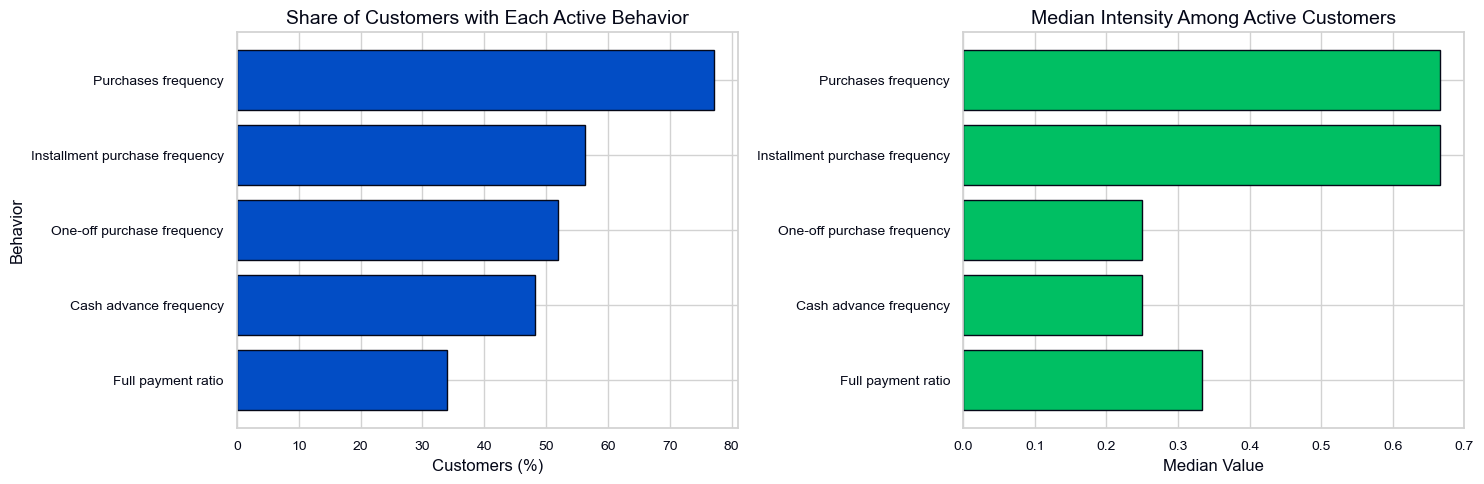

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axes[0].barh(
    y=frequency_summary["behavior"],
    width=frequency_summary["customer_pct_active"],
    color=PROJECT_COLORS["primary_blue"],
    edgecolor=PROJECT_COLORS["deep_navy"])
axes[0].set_title("Share of Customers with Each Active Behavior")
axes[0].set_xlabel("Customers (%)")
axes[0].set_ylabel("Behavior")
axes[1].barh(
    y=frequency_summary["behavior"],
    width=frequency_summary["median_among_active"],
    color=PROJECT_COLORS["green"],
    edgecolor=PROJECT_COLORS["deep_navy"])
axes[1].set_title("Median Intensity Among Active Customers")
axes[1].set_xlabel("Median Value")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_frequency_behavior_summary.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

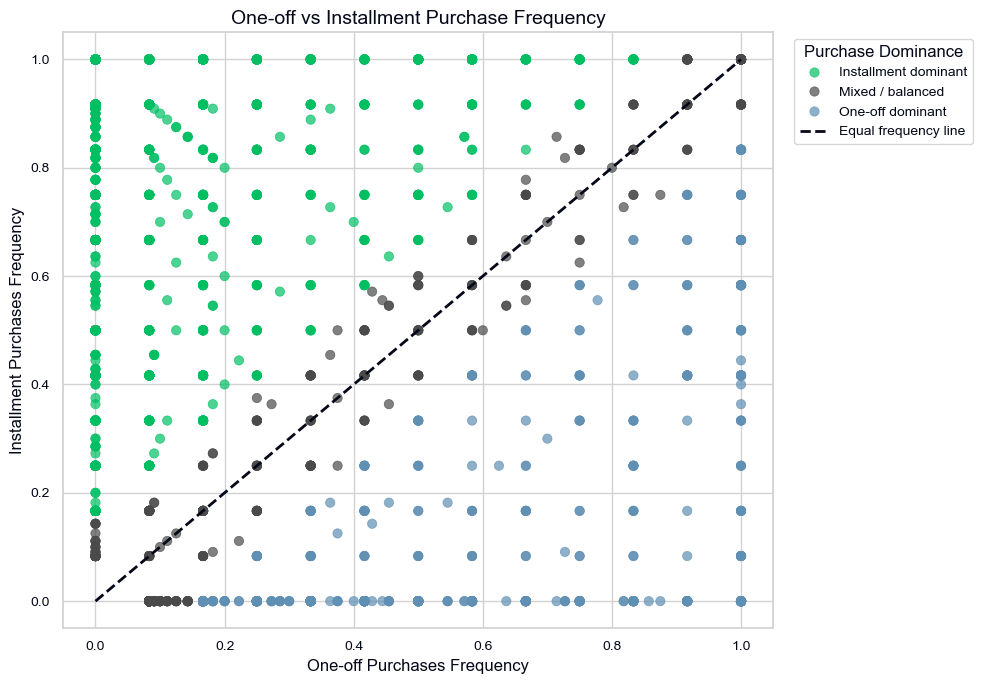

In [ ]:
# Create a temporary dataset for purchase-channel dominance analysis
purchase_channel_df = df_eda[
    [
        "made_purchases",
        "ONEOFF_PURCHASES_FREQUENCY",
        "PURCHASES_INSTALLMENTS_FREQUENCY",
        "PURCHASES_FREQUENCY",
        "PURCHASES_TRX"]].copy()

# Keep only customers who made at least one purchase
purchase_channel_df = purchase_channel_df[purchase_channel_df["made_purchases"] == 1].copy()

# Create a dominance label based on the gap between one-off and installment frequency
purchase_channel_df["purchase_dominance"] = np.select(
    [
        purchase_channel_df["ONEOFF_PURCHASES_FREQUENCY"] > purchase_channel_df["PURCHASES_INSTALLMENTS_FREQUENCY"] + 0.15,
        purchase_channel_df["PURCHASES_INSTALLMENTS_FREQUENCY"] > purchase_channel_df["ONEOFF_PURCHASES_FREQUENCY"] + 0.15
    ],
    [
        "One-off dominant",
        "Installment dominant"
    ],
    default="Mixed / balanced")

purchase_channel_sample = purchase_channel_df.sample(
    n=min(3000, len(purchase_channel_df)),
    random_state=42)

purchase_dominance_colors = {
    "One-off dominant": PROJECT_COLORS["soft_azure"],
    "Installment dominant": PROJECT_COLORS["green"],
    "Mixed / balanced": PROJECT_COLORS["dark_gray"]}


plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=purchase_channel_sample,
    x="ONEOFF_PURCHASES_FREQUENCY",
    y="PURCHASES_INSTALLMENTS_FREQUENCY",
    hue="purchase_dominance",
    palette=purchase_dominance_colors,
    alpha=0.70,
    s=45,
    edgecolor=None)
plt.plot(
    [0, 1],
    [0, 1],
    color=PROJECT_COLORS["deep_navy"],
    linestyle="--",
    linewidth=2,
    label="Equal frequency line")
plt.title("One-off vs Installment Purchase Frequency")
plt.xlabel("One-off Purchases Frequency")
plt.ylabel("Installment Purchases Frequency")
plt.legend(title="Purchase Dominance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "05_oneoff_vs_installment_purchase_frequency.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

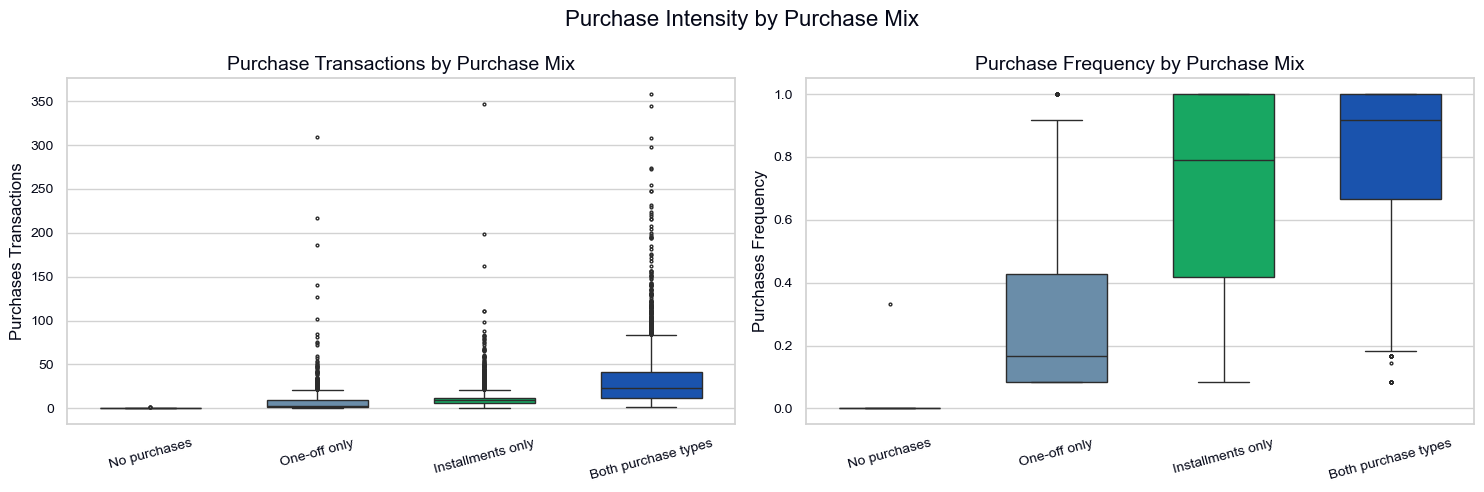

In [ ]:
# Create a temporary dataset for purchase-mix comparison
purchase_mix_plot_df = df_eda[
    [
        "made_purchases",
        "used_oneoff_purchases",
        "used_installments",
        "PURCHASES_TRX",
        "PURCHASES_FREQUENCY"]].copy()

# Create a temporary purchase-mix group for plotting only
purchase_mix_plot_df["purchase_mix_group"] = np.select(
    [
        purchase_mix_plot_df["made_purchases"] == 0,
        (purchase_mix_plot_df["used_oneoff_purchases"] == 1) & (purchase_mix_plot_df["used_installments"] == 0),
        (purchase_mix_plot_df["used_oneoff_purchases"] == 0) & (purchase_mix_plot_df["used_installments"] == 1),
        (purchase_mix_plot_df["used_oneoff_purchases"] == 1) & (purchase_mix_plot_df["used_installments"] == 1)
    ],
    [
        "No purchases",
        "One-off only",
        "Installments only",
        "Both purchase types"
    ],
    default="Other")

# Keep only the expected categories
purchase_mix_order = [
    "No purchases",
    "One-off only",
    "Installments only",
    "Both purchase types"]

purchase_mix_colors = {
    "No purchases": PROJECT_COLORS["dark_gray"],
    "One-off only": PROJECT_COLORS["soft_azure"],
    "Installments only": PROJECT_COLORS["green"],
    "Both purchase types": PROJECT_COLORS["primary_blue"]}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.boxplot(
    data=purchase_mix_plot_df,
    x="purchase_mix_group",
    y="PURCHASES_TRX",
    order=purchase_mix_order,
    palette=purchase_mix_colors,
    width=0.6,
    fliersize=2,
    ax=axes[0])
axes[0].set_title("Purchase Transactions by Purchase Mix")
axes[0].set_xlabel("")
axes[0].set_ylabel("Purchases Transactions")
axes[0].tick_params(axis="x", rotation=15)
sns.boxplot(
    data=purchase_mix_plot_df,
    x="purchase_mix_group",
    y="PURCHASES_FREQUENCY",
    order=purchase_mix_order,
    palette=purchase_mix_colors,
    width=0.6,
    fliersize=2,
    ax=axes[1])
axes[1].set_title("Purchase Frequency by Purchase Mix")
axes[1].set_xlabel("")
axes[1].set_ylabel("Purchases Frequency")
axes[1].tick_params(axis="x", rotation=15)
fig.suptitle("Purchase Intensity by Purchase Mix", fontsize=16)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_purchase_intensity_by_purchase_mix.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [17]:
# Create a temporary DataFrame for credit-capacity and utilization analysis
credit_plot_df = df_eda[
    [
        "BALANCE",
        "CREDIT_LIMIT",
        "PURCHASES",
        "PAYMENTS",
        "MINIMUM_PAYMENTS",
        "CASH_ADVANCE"]].copy()

# Create log-transformed variables for scatterplots
credit_plot_df["log_CREDIT_LIMIT"] = np.log1p(credit_plot_df["CREDIT_LIMIT"])
credit_plot_df["log_BALANCE"] = np.log1p(credit_plot_df["BALANCE"])

# Create behavior ratios
credit_plot_df["balance_to_limit"] = credit_plot_df["BALANCE"] / credit_plot_df["CREDIT_LIMIT"]
credit_plot_df["purchases_to_limit"] = credit_plot_df["PURCHASES"] / (credit_plot_df["CREDIT_LIMIT"] + 1)
credit_plot_df["payments_to_minimum"] = credit_plot_df["PAYMENTS"] / (credit_plot_df["MINIMUM_PAYMENTS"] + 1)

# Cap extreme values for visualization only
balance_to_limit_cap = credit_plot_df["balance_to_limit"].quantile(0.99)
purchases_to_limit_cap = credit_plot_df["purchases_to_limit"].quantile(0.99)
payments_to_minimum_cap = credit_plot_df["payments_to_minimum"].quantile(0.99)

credit_plot_df["balance_to_limit_capped"] = credit_plot_df["balance_to_limit"].clip(upper=balance_to_limit_cap)
credit_plot_df["purchases_to_limit_capped"] = credit_plot_df["purchases_to_limit"].clip(upper=purchases_to_limit_cap)
credit_plot_df["payments_to_minimum_capped"] = credit_plot_df["payments_to_minimum"].clip(upper=payments_to_minimum_cap)

# Create a temporary readable group for cash-advance usage
credit_plot_df["cash_advance_group"] = np.where(
    credit_plot_df["CASH_ADVANCE"] > 0,
    "Used cash advance",
    "No cash advance")

# Create utilization bands for plotting only
credit_plot_df["utilization_band"] = np.select(
    [
        credit_plot_df["balance_to_limit"] == 0,
        credit_plot_df["balance_to_limit"] <= 0.10,
        credit_plot_df["balance_to_limit"] <= 0.50,
        credit_plot_df["balance_to_limit"] <= 0.90,
        credit_plot_df["balance_to_limit"] > 0.90
    ],
    [
        "Zero balance",
        "Low utilization",
        "Moderate utilization",
        "High utilization",
        "Very high utilization"
    ],
    default="Other")

# Define a stable band order
utilization_order = [
    "Zero balance",
    "Low utilization",
    "Moderate utilization",
    "High utilization",
    "Very high utilization"]

print(f"Temporary credit plot dataset shape: {credit_plot_df.shape}")

Temporary credit plot dataset shape: (8950, 16)


,customer_pct
utilization_band,
Zero balance,0.8939
Low utilization,33.7654
Moderate utilization,28.7709
High utilization,24.2793
Very high utilization,12.2905


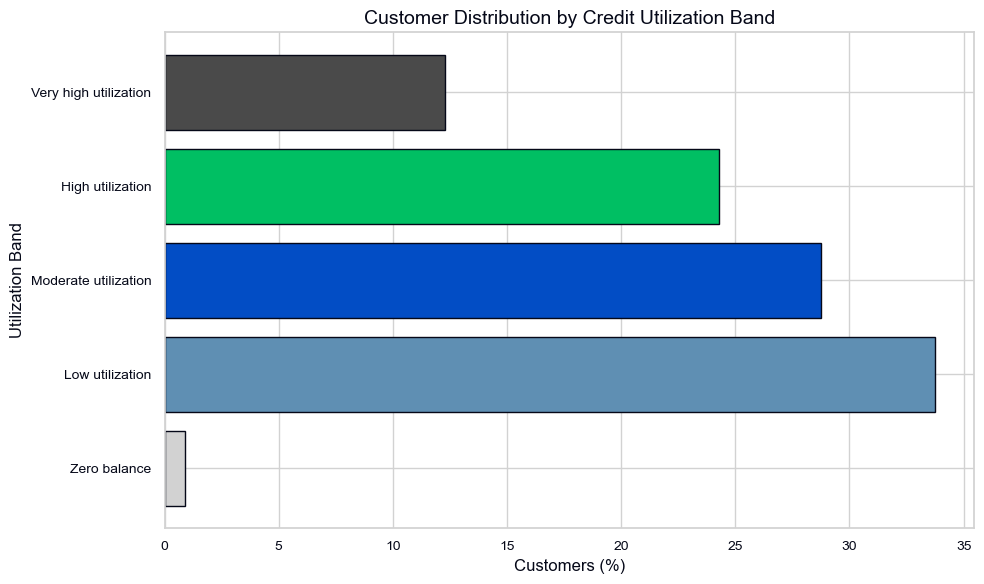

In [ ]:
# Build a summary table for utilization bands
utilization_summary = (
    credit_plot_df["utilization_band"]
    .value_counts(normalize=True)
    .reindex(utilization_order)
    .mul(100)
    .rename("customer_pct")
    .dropna())

# Display the summary table
display(utilization_summary.to_frame())

# Define colors for utilization bands
utilization_colors = {
    "Zero balance": PROJECT_COLORS["light_gray"],
    "Low utilization": PROJECT_COLORS["soft_azure"],
    "Moderate utilization": PROJECT_COLORS["primary_blue"],
    "High utilization": PROJECT_COLORS["green"],
    "Very high utilization": PROJECT_COLORS["dark_gray"]}

plt.figure(figsize=(10, 6))
plt.barh(
    y=utilization_summary.index,
    width=utilization_summary.values,
    color=[utilization_colors[label] for label in utilization_summary.index],
    edgecolor=PROJECT_COLORS["deep_navy"])
plt.title("Customer Distribution by Credit Utilization Band")
plt.xlabel("Customers (%)")
plt.ylabel("Utilization Band")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "07_customer_distribution_by_utilization_band.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

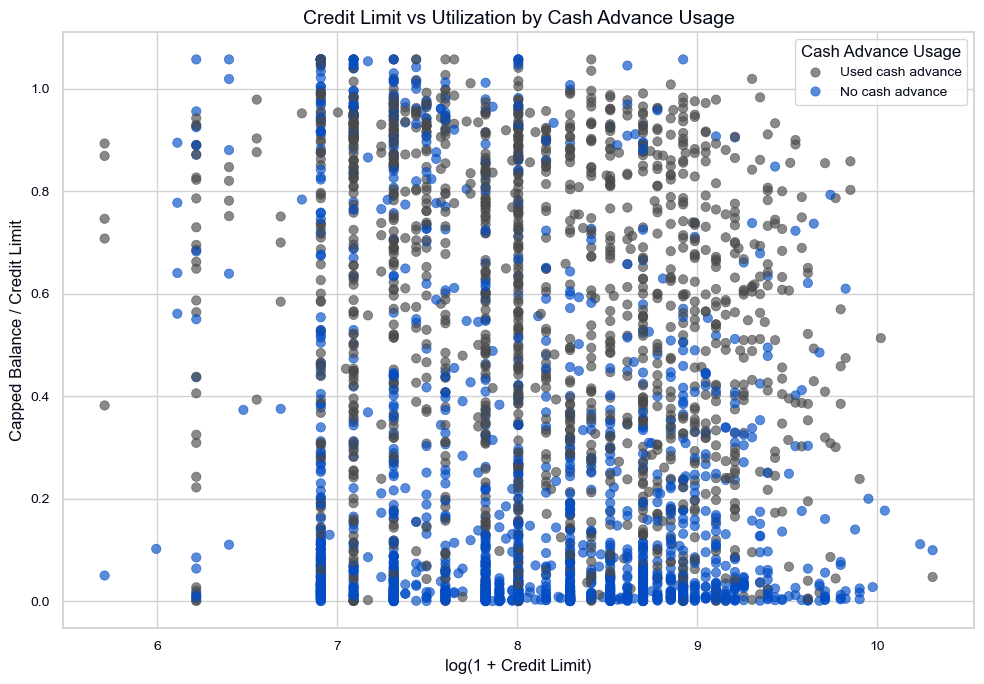

In [ ]:
# Take a reproducible sample to reduce overplotting
credit_scatter_sample = credit_plot_df.sample(
    n=min(3000, len(credit_plot_df)),
    random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=credit_scatter_sample,
    x="log_CREDIT_LIMIT",
    y="balance_to_limit_capped",
    hue="cash_advance_group",
    palette={
        "No cash advance": PROJECT_COLORS["primary_blue"],
        "Used cash advance": PROJECT_COLORS["dark_gray"]
    },
    alpha=0.65,
    s=45,
    edgecolor=None)
plt.title("Credit Limit vs Utilization by Cash Advance Usage")
plt.xlabel("log(1 + Credit Limit)")
plt.ylabel("Capped Balance / Credit Limit")
plt.legend(title="Cash Advance Usage")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "08_credit_limit_vs_utilization_by_cash_advance.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

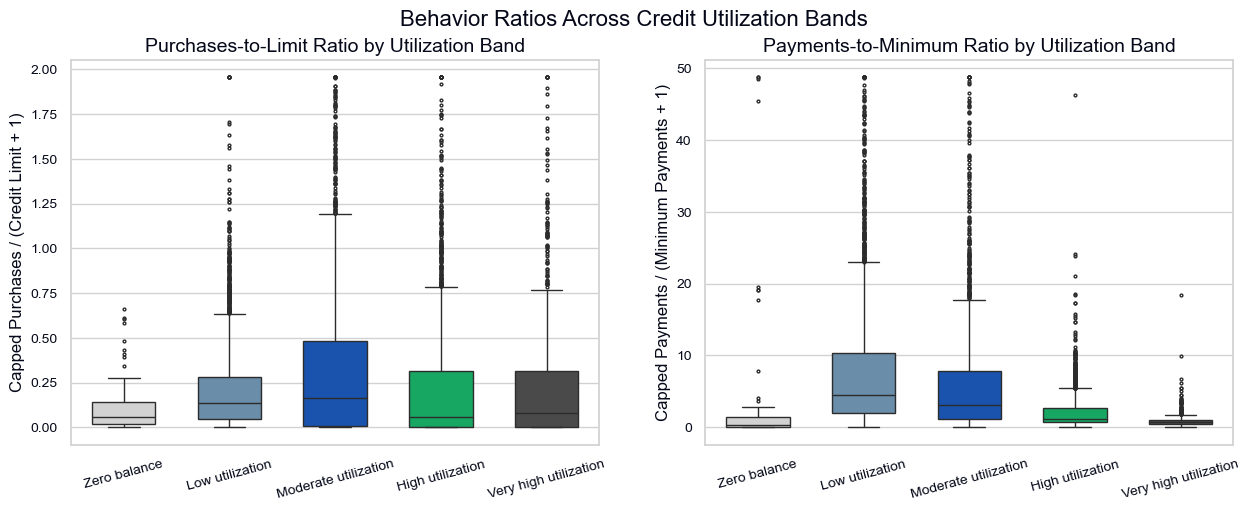

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
sns.boxplot(
    data=credit_plot_df,
    x="utilization_band",
    y="purchases_to_limit_capped",
    order=utilization_order,
    palette=utilization_colors,
    width=0.6,
    fliersize=2,
    ax=axes[0])
axes[0].set_title("Purchases-to-Limit Ratio by Utilization Band")
axes[0].set_xlabel("")
axes[0].set_ylabel("Capped Purchases / (Credit Limit + 1)")
axes[0].tick_params(axis="x", rotation=15)
sns.boxplot(
    data=credit_plot_df,
    x="utilization_band",
    y="payments_to_minimum_capped",
    order=utilization_order,
    palette=utilization_colors,
    width=0.6,
    fliersize=2,
    ax=axes[1])
axes[1].set_title("Payments-to-Minimum Ratio by Utilization Band")
axes[1].set_xlabel("")
axes[1].set_ylabel("Capped Payments / (Minimum Payments + 1)")
axes[1].tick_params(axis="x", rotation=15)
fig.suptitle("Behavior Ratios Across Credit Utilization Bands", fontsize=16)
plt.savefig(
    FIGURES_DIR / "09_behavior_ratios_across_utilization_bands.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

## EDA Summary

The exploratory analysis highlights several meaningful behavioral patterns that support the use of customer segmentation on this dataset.

### Key behavioral findings

- Purchase behavior is heterogeneous:
  - some customers do not purchase at all,
  - some are one-off oriented,
  - some rely mainly on installments,
  - and a large group uses both purchase types.
- Customers using both purchase types generally show higher purchase intensity, both in terms of transaction count and purchase frequency.
- Purchase-related behaviors are not evenly distributed, suggesting that distinct behavioral segments may exist.

### Payment and cash-advance behavior

- Customers with cash-advance activity tend to show more stressed financial profiles, especially in terms of balance relative to credit limit.
- Customers with full-payment activity tend to display stronger payment behavior relative to their outstanding balance.
- The relationship between balance and payments appears structured rather than random, which is encouraging for downstream segmentation.

### Frequency patterns

- Purchase frequency is the most common active behavior in the dataset.
- Installment purchase frequency is also relatively common and often stronger than one-off frequency for many customers.
- Cash-advance activity is less common than purchase activity, but still substantial enough to represent a meaningful behavioral dimension.

### Credit utilization patterns

- Most customers have non-zero balances.
- A sizeable share of customers falls into moderate, high, or very high utilization bands.
- Cash-advance users appear more concentrated in higher-utilization regions.
- Payment behavior varies across utilization bands, suggesting that credit usage intensity and repayment behavior may jointly define important customer groups.

### EDA conclusion

Overall, the dataset shows clear variation across:
- purchase type,
- purchase intensity,
- payment behavior,
- cash-advance usage,
- and credit utilization.

These patterns support the idea that meaningful behavioral clusters may emerge after proper preprocessing and clustering model comparison.

### Note on interpretation support

Because this dataset includes financial and credit-related behavioral variables, ChatGPT was used as an auxiliary interpretation tool to help clarify domain-specific meanings during the exploratory phase. This support was limited to improving understanding of the variables, shaping temporary plotting DataFrames, and assigning readable labels for visual communication, while all analysis logic, preprocessing decisions, and modeling steps remained grounded in the dataset itself.